# LSTM Overview

## 1. What is LSTM?

**LSTM (Long Short-Term Memory)** is a specialized type of Recurrent Neural Network (RNN) designed to work with **sequential/time-series data**.  
It can **remember past patterns for long periods** using internal memory and gates.  
### Purpose of LSTM in time-series:
- To learn trends and temporal dependencies over time.
- To forecast future values based on historical data.
- Useful for problems like air-quality prediction, weather forecasting, stock prediction, etc.





In [1]:
from google.colab import drive

# Monter le Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Import libraries here
import inspect
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import pytz
from IPython.display import VimeoVideo
from glob import glob

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_model import ARMA
from statsmodels.tsa.ar_model import AutoReg
from pandas import MultiIndex, Int16Dtype
import xgboost as xgb
from pandas import Timestamp
import statsmodels.api as sm
from statsmodels.graphics.api import qqplot
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
#from tensorflow.keras.utils import TimeseriesGenerator
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
import tensorflow as tf
# The following two lines are causing the RuntimeError because they disable TensorFlow 2.x behavior
# import tensorflow.compat.v1 as tf
# tf.compat.v1.disable_v2_behavior()

# sensors.AFRICA Air Quality Archive Abuja

## Dataset Info
**Source:** sensors.AFRICA / openAFRICA  

Air-quality measurements in Abuja from multiple sensors and locations, suitable for **time-series analysis and PM2.5 forecasting**.

### Key Variables
| Variable | Meaning |
|----------|---------|
| `timestamp` | Date & time |
| `sensor_id` | Sensor ID |
| `sensor_type` | Sensor type |
| `location` | Physical location |
| `lat`, `lon` | Coordinates |
| `value_type` | Parameter type |
| `value` | Measurement |
| `P0` | PM1 |
| `P2` | PM2.5 |
| `P1` | PM10 |
| `temperature` | Ambient temperature (°C) |
| `humidity` | Relative humidity (%) |

> PM1 = P0, PM2.5 = P2, PM10 = P1

## Data Format
- CSV files, each row = one sensor reading.  
- Ready for **resampling, cleaning, and LSTM modeling**.

## Use Cases
- Visualize air-quality trends.  
- Forecast PM levels with LSTM/ML.  
- Analyze daily/seasonal pollution patterns.  
- Study correlation with weather variables.  
- Detect anomalies and peaks.


In [3]:
from glob import glob

folder_path = '/content/drive/My Drive/AIR QUALITY IN ABUJA/'


files = glob(folder_path + "Sensor_Data_*")


print(files)

['/content/drive/My Drive/AIR QUALITY IN ABUJA/Sensor_Data_Nov_2022.csv', '/content/drive/My Drive/AIR QUALITY IN ABUJA/Sensor_Data_Dec_2022.csv', '/content/drive/My Drive/AIR QUALITY IN ABUJA/Sensor_Data_Jan_2023.csv', '/content/drive/My Drive/AIR QUALITY IN ABUJA/Sensor_Data_Fev_2023.csv', '/content/drive/My Drive/AIR QUALITY IN ABUJA/Sensor_Data_Mars_2023.csv', '/content/drive/My Drive/AIR QUALITY IN ABUJA/Sensor_Data_April_2023.csv', '/content/drive/My Drive/AIR QUALITY IN ABUJA/Sensor_Data_May_2023.csv', '/content/drive/My Drive/AIR QUALITY IN ABUJA/Sensor_Data_June_2023.csv', '/content/drive/My Drive/AIR QUALITY IN ABUJA/Sensor_Data_June_2023_copy.csv']


### `wrangle(files, resample_rule="1D")`
Loads multiple CSV files, cleans timestamps, keeps PM2.5 readings, removes outliers, converts time to Africa/Lagos, and resamples the data (daily by default) to produce a clean time-series for analysis or modeling.


In [4]:
def wrangle(files, resample_rule="1D"):
    # Read all CSV files and concatenate
    df = pd.concat([pd.read_csv(file, sep=';') for file in files]).copy()

    # Convert timestamp to datetime, handle ISO8601 and mixed formats
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)

    # Remove rows with invalid timestamps
    df = df.dropna(subset=['timestamp'])

    # Set datetime index
    df = df.set_index('timestamp')

    # Convert UTC to Nigeria time
    df.index = df.index.tz_convert('Africa/Lagos')

    # Keep only PM2.5 readings and remove outliers (>250)
    df = df[(df["value_type"] == "P2") & (df["value"] < 250)]

    # Resample to desired interval and forward-fill missing values
    df_resampled = df["value"].resample(resample_rule).mean().fillna(method='ffill')

    return df_resampled


In [5]:
import pandas as pd
df = wrangle(files, resample_rule="1D")
print(df.shape)
df.head(10)

(237,)


,value
timestamp,
2022-11-07 00:00:00+01:00,16.162925
2022-11-08 00:00:00+01:00,25.440841
2022-11-09 00:00:00+01:00,38.139241
2022-11-10 00:00:00+01:00,39.913696
2022-11-11 00:00:00+01:00,45.637721
2022-11-12 00:00:00+01:00,37.441174
2022-11-13 00:00:00+01:00,56.644478
2022-11-14 00:00:00+01:00,37.736617
2022-11-15 00:00:00+01:00,34.199252


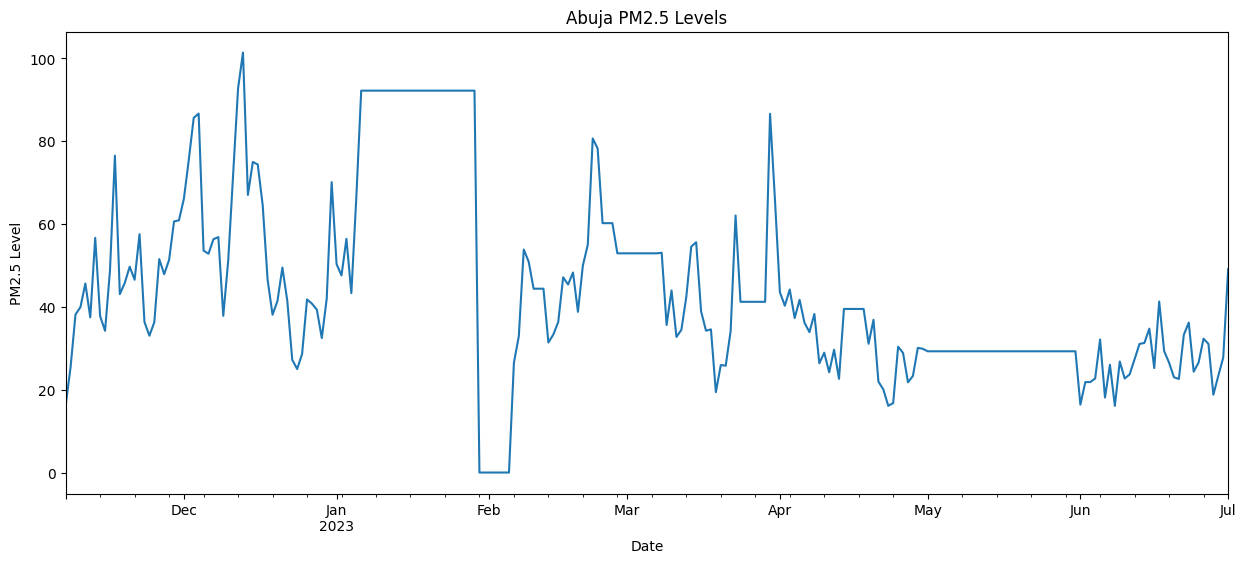

In [6]:
import os
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(15, 6))
df.plot(xlabel="Date", ylabel="PM2.5 Level", title="Abuja PM2.5 Levels", ax=ax);

# Create the directory if it doesn't exist
if not os.path.exists("images"):
    os.makedirs("images")

# Don't delete the code below 👇
plt.savefig("images/3-5-5.png", dpi=150)

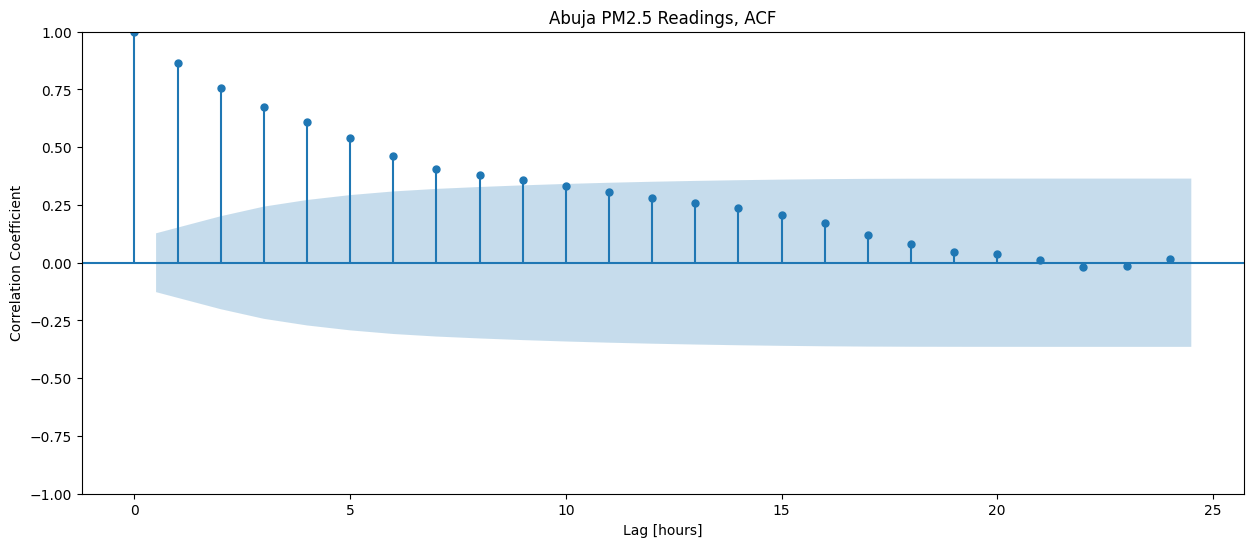

In [7]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(df, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Abuja PM2.5 Readings, ACF");
# Don't delete the code below 👇
plt.savefig("images/3-5-7.png", dpi=150)

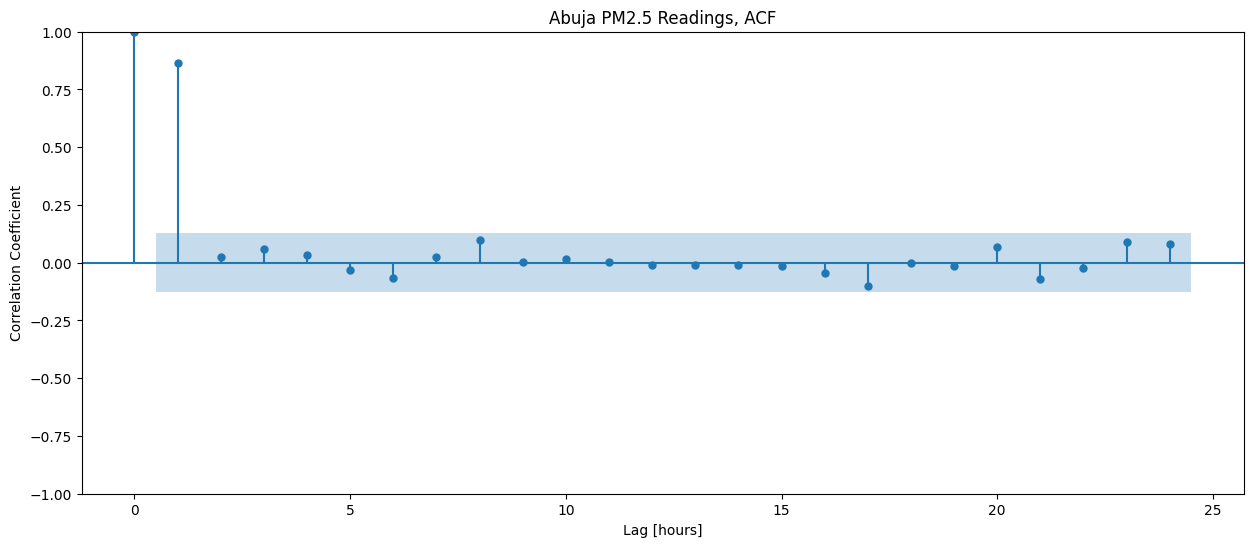

In [8]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(df, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Abuja PM2.5 Readings, ACF");
# Don't delete the code below 👇
plt.savefig("images/3-5-7.png", dpi=150)

In [9]:
# Generate corresponding dates for the time series
start_date = pd.to_datetime('2022-11-07')
date_range = pd.date_range(start_date, periods=len(df), freq='D')

In [10]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df.values.reshape(-1, 1))

In [ ]:
data_scaled

array([[0.1594416 ],
       [0.25096499],
       [0.37623026],
       [0.39373464],
       [0.45020015],
       [0.36934408],
       [0.55877795],
       [0.37225852],
       [0.33736365],
       [0.48128063],
       [0.75455445],
       [0.42470182],
       [0.4513326 ],
       [0.49008384],
       [0.4589872 ],
       [0.5675234 ],
       [0.35836582],
       [0.32579215],
       [0.3578563 ],
       [0.50823257],
       [0.47220846],
       [0.50607457],
       [0.59777725],
       [0.60052399],
       [0.65155693],
       [0.74473626],
       [0.84455639],
       [0.8546429 ],
       [0.52829988],
       [0.52086487],
       [0.55554996],
       [0.56057696],
       [0.37309565],
       [0.50433184],
       [0.71130058],
       [0.91437156],
       [1.        ],
       [0.66086725],
       [0.73945094],
       [0.73335252],
       [0.63683021],
       [0.45903506],
       [0.37567976],
       [0.40844056],
       [0.4880306 ],
       [0.40841747],
       [0.26838415],
       [0.246

In [11]:
# Define the number of previous time steps to use for prediction
look_back = 10

In [12]:
X, y = [], []
for i in range(len(data_scaled) - look_back):
    X.append(data_scaled[i : i + look_back])
    y.append(data_scaled[i + look_back])

In [13]:
X, y = np.array(X), np.array(y)
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

y_train shape: (204, 1)
y_test shape: (23, 1)
X_train shape: (204, 10, 1)
X_test shape: (23, 10, 1)


In [14]:
# Calculate baseline metrics
y_train_mean = y_train.mean()
y_pred_baseline = [y_train_mean] * len(y_train)
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)
rmse_baseline = mean_squared_error(y_train, y_pred_baseline)
baseline_r2 = r2_score(y_train, y_pred_baseline)
print("Mean P2 Reading:", y_train_mean)
print("Baseline MAE:", mae_baseline)
print("Baseline RMSE:", rmse_baseline)
print("Baseline R2:", baseline_r2)

Mean P2 Reading: 0.44199352569516837
Baseline MAE: 0.18350391034069088
Baseline RMSE: 0.0539909239258715
Baseline R2: 0.0


In [15]:
import tensorflow as tf

tf.config.run_functions_eagerly(True)  # optional, forces eager mode
# or check
print(tf.executing_eagerly())  # should return True


True


In [16]:
# Create the LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(look_back, 1)))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=64)

# Make predictions
y_pred = model.predict(X_test)

# # Inverse transform to get original scale
# y_test_original = scaler.inverse_transform(y_test)
# y_pred_original = scaler.inverse_transform(y_pred)

# Calculate metrics for the LSTM model
lstm_mae = mean_absolute_error(y_test, y_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lstm_r2 = r2_score(y_test, y_pred)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.2473
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.2048
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.1786
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.1536
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.1229
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0834
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0605
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0405
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0301
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0355
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0314
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0261
Epoch 13/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0271
Epoch 14/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.0259
Epoch 15/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0266
Epoch 16/50
4/4 ━━━━━━━━━━━━━━━━━

In [17]:

print(f"Baseline MAE: {mae_baseline:.4f}, RMSE: {rmse_baseline:.4f}, R2: {baseline_r2:.4f}")
print(f"LSTM Model MAE: {lstm_mae:.4f}, RMSE: {lstm_rmse:.4f}, R2: {lstm_r2:.4f}")

Baseline MAE: 0.1835, RMSE: 0.0540, R2: 0.0000
LSTM Model MAE: 0.1256, RMSE: 0.1888, R2: 0.0629


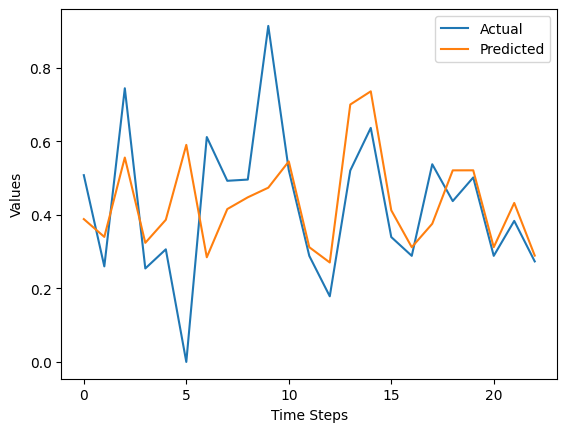

In [18]:

# Visualize the results
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Values')
plt.legend()
plt.show()